<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-2-b3fdaf15785b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


#### Task 1

#### Display the first 5 rows of the dataset.

In [13]:
print(boston_df.head())

   Unnamed: 0     CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  \
0           0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0   
1           1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0   
2           2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0   
3           3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0   
4           4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0   

     TAX  PTRATIO  LSTAT  MEDV  
0  296.0     15.3   4.98  24.0  
1  242.0     17.8   9.14  21.6  
2  242.0     17.8   4.03  34.7  
3  222.0     18.7   2.94  33.4  
4  222.0     18.7   5.33  36.2  


#### Display the data types of each column

In [14]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.4 KB


#### Check for missing values in each column

In [15]:
boston_df.isnull()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,False,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


#### count missing value in each column

In [9]:
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

#### Check for duplicate rows.

In [10]:
boston_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505    False
Length: 506, dtype: bool

#### Total duplicate rows count

In [11]:
boston_df.duplicated().sum()

0

#### Display the correlation matrix of the dataset

In [12]:
boston_df.corr()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


#### Task 2:

#### Display descriptive statistics of the dataset.

In [17]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


#### Create a boxplot for MEDV (Median value of owner-occupied homes).

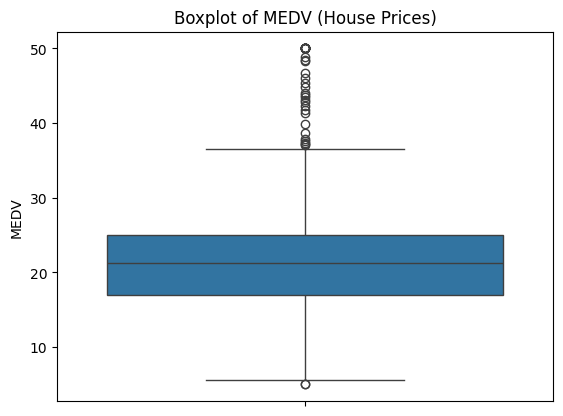

In [19]:
pyplot.figure()
sns.boxplot(y=boston_df['MEDV'])
pyplot.title("Boxplot of MEDV (House Prices)")
pyplot.show()

#### Create a bar plot for CHAS (Charles River dummy variable).

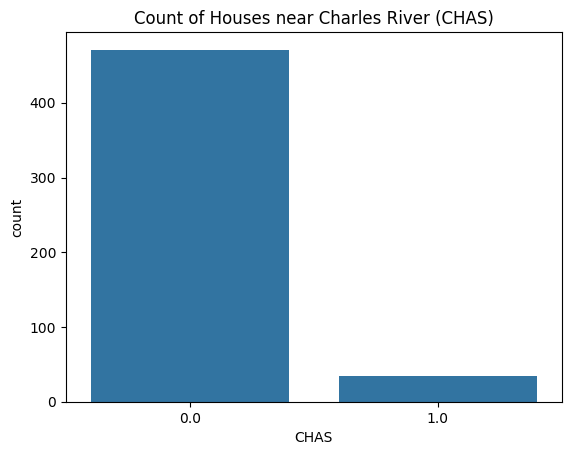

In [21]:
pyplot.figure()
sns.countplot(x=boston_df['CHAS'])
pyplot.title("Count of Houses near Charles River (CHAS)")
pyplot.show()

#### Discretize AGE into three groups and create a boxplot of MEDV versus these groups:

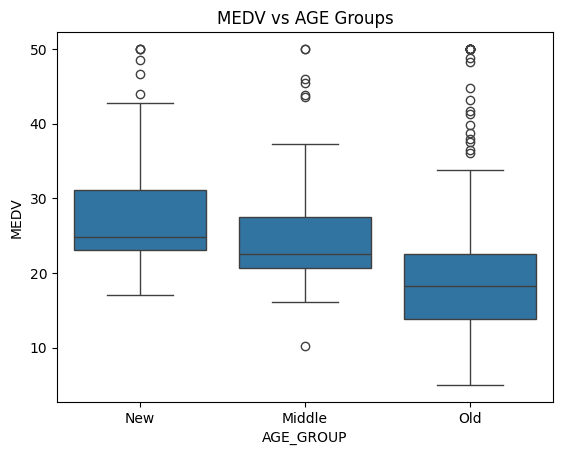

In [26]:
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'],
                         bins=[0, 35, 70, 100],
                         labels=['New', 'Middle', 'Old'])

# Boxplot
pyplot.figure()
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df)
pyplot.title("MEDV vs AGE Groups")
pyplot.show()

#### Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).

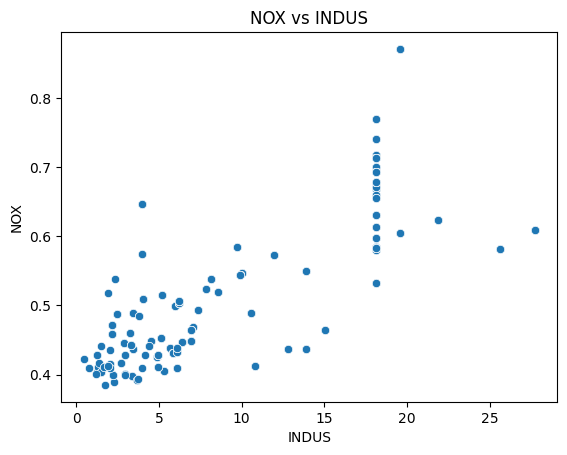

In [28]:
pyplot.figure()
sns.scatterplot(x=boston_df['INDUS'], y=boston_df['NOX'])
pyplot.title("NOX vs INDUS")
pyplot.show()

#### Create a histogram for PTRATIO (pupil-teacher ratio)

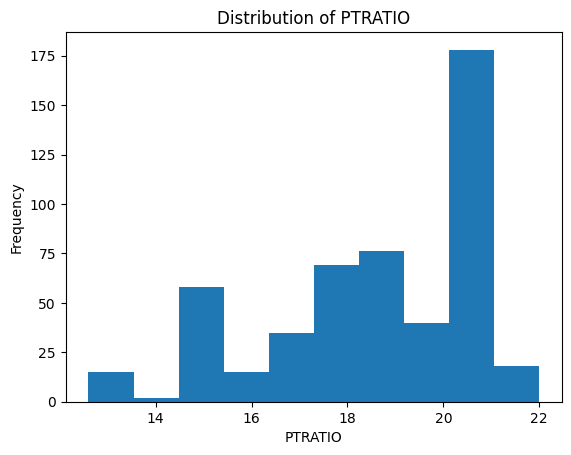

In [30]:
pyplot.figure()
pyplot.hist(boston_df['PTRATIO'])
pyplot.title("Distribution of PTRATIO")
pyplot.xlabel("PTRATIO")
pyplot.ylabel("Frequency")
pyplot.show()

#### Task 3:

#### Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.

In [35]:
import scipy.stats as stats
# To make CHAS groups 
group1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
group0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

# Levene Test
levene_stat, p_value = stats.levene(group1, group0)

print("Levene Test Statistic:", levene_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Variances are NOT equal")
else:
    print("Variances are equal")

Levene Test Statistic: 4.590342218715871
p-value: 0.03263097600633006
Variances are NOT equal


#### Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River.

In [36]:
t_stat, p_value = stats.ttest_ind(group1, group0)

print("T-test Statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Significant difference in MEDV")
else:
    print("No significant difference in MEDV")

T-test Statistic: 3.996437466090509
p-value: 7.390623170519905e-05
Significant difference in MEDV


#### Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier.

In [39]:
# Groups
new = boston_df[boston_df['AGE_GROUP'] == 'New']['MEDV']
mid = boston_df[boston_df['AGE_GROUP'] == 'Middle']['MEDV']
old = boston_df[boston_df['AGE_GROUP'] == 'Old']['MEDV']

# ANOVA
anova_stat, p_value = stats.f_oneway(new, mid, old)

print("ANOVA Statistic:", anova_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("At least one group is different")
else:
    print("No significant difference among groups")

ANOVA Statistic: 36.40764999196599
p-value: 1.7105011022702984e-15
At least one group is different


#### Perform a Pearson correlation test to assess the relationship between NOX and INDUS.

In [40]:
corr, p_value = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

print("Correlation:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("Significant relationship exists")
else:
    print("No significant relationship")

Correlation: 0.7636514469209192
p-value: 7.913361061210442e-98
Significant relationship exists


#### Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results.

In [42]:
# Independent (X) and dependent (y)
X = boston_df['DIS']
y = boston_df['MEDV']

# TO add constant is necessary 
X = sm.add_constant(X)

# Model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.21e-08
Time:                        21:32:58   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0